<a href="https://colab.research.google.com/github/bobo33772-blip/AI_study/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_9_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 패션 mnist를 cnn으로 학습하기
import keras
from sklearn.model_selection import train_test_split
# 패션 mnist 로딩
(train_input,train_target),(test_input,test_target) = \
keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_input.shape

(60000, 28, 28)

In [4]:
train_scaled = train_input.reshape(-1,28,28,1)
train_scaled.shape

(60000, 28, 28, 1)

In [5]:
# train_test_split()적용
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    train_scaled,
    train_target,
    test_size=0.2,
    random_state=42
)

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
#도형의 기초형태를 추출(가로,세로,사선,원호,...)
model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'))
model.add((keras.layers.MaxPooling2D(2)))
model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'))
model.add((keras.layers.MaxPooling2D(2)))
model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'))
model.add((keras.layers.MaxPooling2D(2)))
model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'))
model.add((keras.layers.MaxPooling2D(2)))
model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'))
model.add((keras.layers.MaxPooling2D(2)))

In [7]:
model.add(keras.layers.Flatten()) # 1차원으로 변환
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dropout(0.4))
# 10 가지 종류중 1개로 분류
model.add(keras.layers.Dense(10,activation='softmax'))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # 다중분류 loss
    metrics=['accuracy']
)
cp_cb = keras.callbacks.ModelCheckpoint(
    'best-cnn-model.h5',
    save_best_only=True
)
es_cb = keras.callbacks.EarlyStopping(
    patience=2, ## loss변화없는 횟수
    restore_best_weights=True # 최고의 가중치 자동 학습
)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2, # 학습 확인용 데이터 비율(검증)
    epochs=50,
    batch_size=200,
    callbacks=[es_cb,cp_cb], # early stop 최고 점수 나왔을 때 멈춤
    # verbose=0 # 학습 메세지 안보임
)
# 192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5510 - loss: 5.7654WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`.
# 192/192 ━━━━━━━━━━━━━━━━━━━━ 63s 321ms/step - accuracy: 0.6915 - loss: 1.8436 - val_accuracy: 0.8490 - val_loss: 0.4161
# Epoch 2/50
# 122/192 ━━━━━━━━━━━━━━━━━━━━ 16s 230ms/step - accuracy: 0.8184 - loss: 0.5152


Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5424 - loss: 6.4501

192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 226ms/step - accuracy: 0.6668 - loss: 2.0093 - val_accuracy: 0.8390 - val_loss: 0.4691
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7954 - loss: 0.5731

192/192 ━━━━━━━━━━━━━━━━━━━━ 80s 219ms/step - accuracy: 0.8053 - loss: 0.5435 - val_accuracy: 0.8641 - val_loss: 0.3817
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8338 - loss: 0.4618

192/192 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.8373 - loss: 0.4543 - val_accuracy: 0.8759 - val_loss: 0.3450
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8469 - loss: 0.4244

192/192 ━━━━━━━━━━━━━━━━━━━━ 43s 223ms/step - accuracy: 0.8511 - loss: 0.4101 - val_accuracy: 0.8828 - val_loss: 0.3181
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8662 - loss: 0.3627

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.8797 - loss: 0.3247 - val_accuracy: 0.8969 - val_loss: 0.2864
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8878 - loss: 0.3023

192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.8859 - loss: 0.3080 - val_accuracy: 0.8972 - val_loss: 0.2863
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8915 - loss: 0.2897

192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.8899 - loss: 0.2944 - val_accuracy: 0.8998 - val_loss: 0.2844
Epoch 10/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8961 - loss: 0.2733

192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.8955 - loss: 0.2781 - val_accuracy: 0.9071 - val_loss: 0.2703
Epoch 11/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 82s 217ms/step - accuracy: 0.8987 - loss: 0.2683 - val_accuracy: 0.9033 - val_loss: 0.2729
Epoch 12/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9047 - loss: 0.2530

192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 218ms/step - accuracy: 0.9033 - loss: 0.2561 - val_accuracy: 0.9072 - val_loss: 0.2647
Epoch 13/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 84s 228ms/step - accuracy: 0.9056 - loss: 0.2493 - val_accuracy: 0.9048 - val_loss: 0.2727
Epoch 14/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.9085 - loss: 0.2397 - val_accuracy: 0.9072 - val_loss: 0.2738


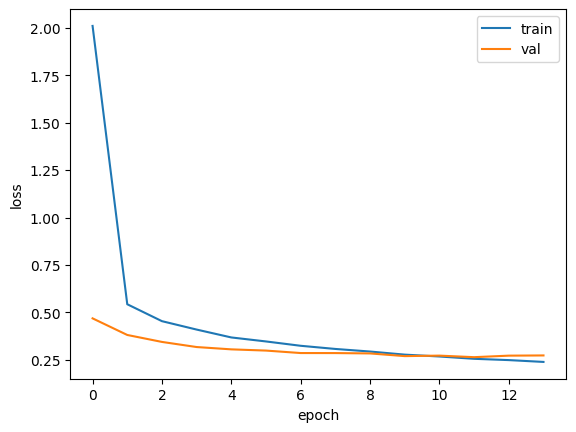

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])

In [11]:
model.evaluate(X_test,y_test)

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9034 - loss: 0.2720


[0.2720395624637604, 0.9034166932106018]

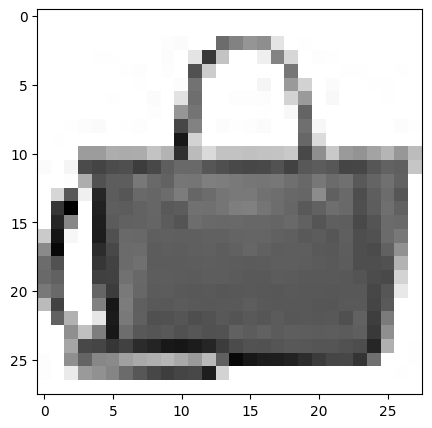

In [12]:
plt.figure(figsize=(5,5))
plt.imshow(X_test[0].reshape(28,28),cmap='gray_r')
plt.show()

In [13]:
pred = model.predict(X_test[0].reshape(-1,28,28,1))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
[[9.5595785e-26 2.0648607e-31 3.0922010e-23 3.2304095e-27 3.5708012e-28
  1.5777529e-22 1.8831013e-21 6.0585403e-28 1.0000000e+00 9.3468771e-23]]


In [14]:
import numpy as np
np.argmax(pred)

np.int64(8)